In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 12
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

font_path = os.path.join('..', 'other', 'Roboto', 'Roboto-Regular.ttf')
font_prop = FontProperties(fname = font_path)
fm.fontManager.addfont(font_path)
custom_font_name = font_prop.get_name()

font_path_bold = os.path.join('..', 'other', 'Roboto', 'Roboto-Bold.ttf')
font_prop_bold = FontProperties(fname = font_path_bold)

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = custom_font_name
plt.rcParams['axes.unicode_minus'] = True

In [3]:
economics_results_file = 'production_costs.xlsx'
climate_change_results_file = 'climate_change_impact.xlsx'

In [4]:
economics_df = pd.read_excel(os.path.join('..', 'results', economics_results_file), sheet_name = 'overall_2020', index_col = 0)
economics_df_final = economics_df.drop(columns = ['Total', 'Low', 'High'])
economics_df_final

,Scenario,Coke,Methane,Heating,Electricity,Other utilities,Direct emissions
0,Calcium carbide,0.168116,0.000000,0.000000,1.009963,0.000604,0
1,Partial combustion,0.000000,1.633309,0.094293,0.308321,0.000150,0
2,Thermal plasma,0.000000,0.569097,0.083816,1.131198,0.000290,0
3,Non-thermal plasma,0.000000,0.421132,0.000000,1.182616,0.000000,0
4,Calcium carbide,0.542106,0.000000,0.000000,1.009963,0.000604,0
5,Partial combustion,0.000000,8.541998,0.094293,0.308321,0.000150,0
6,Thermal plasma,0.000000,2.976306,0.083816,1.131198,0.000290,0
7,Non-thermal plasma,0.000000,2.202466,0.000000,1.182616,0.000000,0


In [5]:
climate_change_df = pd.read_excel(os.path.join('..', 'results', climate_change_results_file), sheet_name = 'overall_2020', index_col = 0)
climate_change_df_final = climate_change_df.drop(columns = ['Total', '2050 Total', 'STDEV', 'Low', 'High'])
climate_change_df_final

,Scenario,Coke,Methane,Heating,Electricity,Other utilities,Direct emissions
0,Calcium carbide,1.838287,0.000000,0.000000,7.337633,0.172487,3.601439
1,Partial combustion,0.000000,3.135920,1.569122,2.239700,0.067908,0.800000
2,Thermal plasma,0.000000,1.092655,1.394776,8.217214,0.064981,0.000000
3,Non-thermal plasma,0.000000,1.040624,0.000000,8.590724,0.000000,0.000000
4,Calcium carbide,-7.715378,0.000000,0.000000,7.337633,0.172487,3.601439
5,Partial combustion,0.000000,-10.805943,1.569122,2.239700,0.067908,0.800000
6,Thermal plasma,0.000000,-3.765137,1.394776,8.217214,0.064981,0.000000
7,Non-thermal plasma,0.000000,-3.585845,0.000000,8.590724,0.000000,0.000000


In [6]:
x_pts = np.arange(0, len(climate_change_df_final))
x_labels = []
for i in range(0, len(x_pts)):
    string = climate_change_df_final['Scenario'][i]
    new = '\n'
    string = new.join(string.rsplit(' ', 1))
    x_labels.append(string)
x_labels

['Calcium\ncarbide',
 'Partial\ncombustion',
 'Thermal\nplasma',
 'Non-thermal\nplasma',
 'Calcium\ncarbide',
 'Partial\ncombustion',
 'Thermal\nplasma',
 'Non-thermal\nplasma']

In [7]:
x_labels = ['CaC$_\mathdefault{2}$', 'PC', 'Thermal\nplasma', 'Non-thermal\nplasma'] * 2
x_labels

['CaC$_\\mathdefault{2}$',
 'PC',
 'Thermal\nplasma',
 'Non-thermal\nplasma',
 'CaC$_\\mathdefault{2}$',
 'PC',
 'Thermal\nplasma',
 'Non-thermal\nplasma']

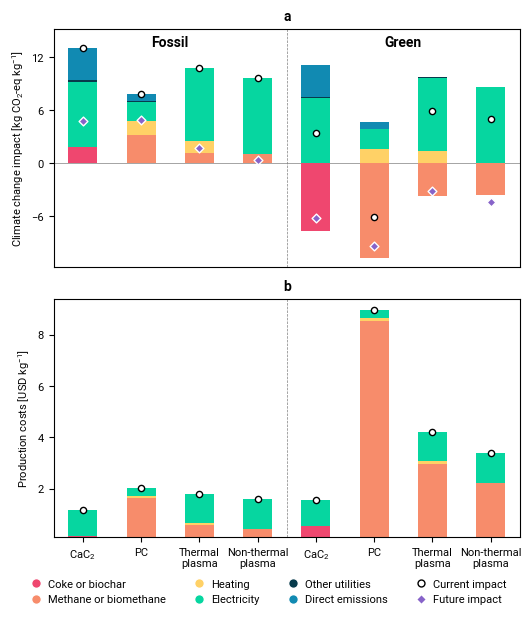

In [8]:
fig, [ax1, ax2] = plt.subplots(2, 1, figsize = (fig_length[1.5], fig_height*0.6))

colors = ['#ef476f', '#f78c6b', '#ffd166', '#06d6a0', '#073b4c', '#118ab2'] 

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impact [kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$]')
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax1.scatter(x_pts, climate_change_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax1.scatter(x_pts, climate_change_df['2050 Total'], s = 20, facecolor = '#8763c9', edgecolors = '#ffffff', marker = 'D', zorder = 1)
ax1.set_title('a', fontproperties = font_prop_bold)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax1.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.set_ylim([-11.8, 15.2])
ax1.text(1.5, 13.2, 'Fossil', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.text(5.5, 13.2, 'Green', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.set_xticks([])

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
ax2.legend([], frameon = False)
ax2.set_ylabel('Production costs [USD kg$^\mathdefault{-1}$]')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax2.scatter(x_pts, economics_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax2.set_title('b', fontproperties = font_prop_bold)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax2.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.set_ylim([0.1, 9.4])
# ax2.text(1.5, 4.6, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax2.text(5.5, 4.6, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax2.yaxis.set_major_locator(MaxNLocator(5))

labels = ['Coke or biochar', 'Methane or biomethane', 'Heating', 'Electricity', 'Other utilities', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#8763c9', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 4, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'plots', 'main_figure')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)

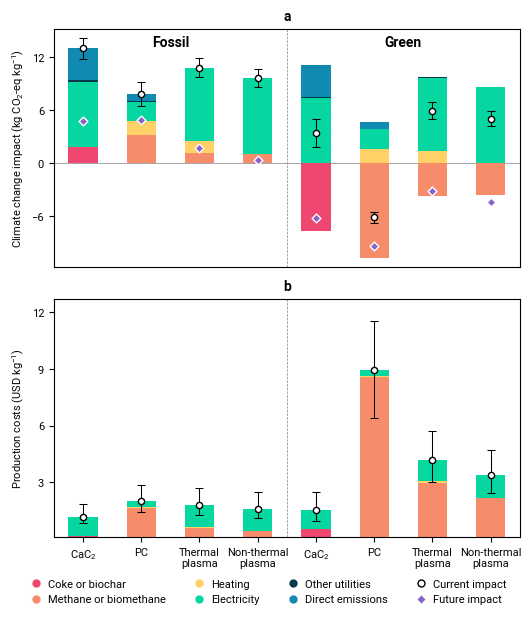

In [9]:
fig, [ax1, ax2] = plt.subplots(2, 1, figsize = (fig_length[1.5], fig_height*0.6))

colors = ['#ef476f', '#f78c6b', '#ffd166', '#06d6a0', '#073b4c', '#118ab2'] 

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impact (kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$)')
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax1.scatter(x_pts, climate_change_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax1.scatter(x_pts, climate_change_df['2050 Total'], s = 20, facecolor = '#8763c9', edgecolors = '#ffffff', marker = 'D', zorder = 2)
ax1.set_title('a', fontproperties = font_prop_bold)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax1.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.errorbar(x_pts, climate_change_df['Total'], yerr = 2 * climate_change_df['STDEV'], fmt = 'none', ecolor = '#000000', elinewidth = 0.75, capsize = 3, capthick = 0.75, zorder = 1)
ax1.set_ylim([-11.8, 15.2])
ax1.text(1.5, 13.2, 'Fossil', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.text(5.5, 13.2, 'Green', ha = 'center', color = '#000000', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.set_xticks([])

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
ax2.legend([], frameon = False)
ax2.set_ylabel('Production costs (USD kg$^\mathdefault{-1}$)')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax2.scatter(x_pts, economics_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000', zorder = 2)
ax2.set_title('b', fontproperties = font_prop_bold)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax2.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.set_ylim([0.1, 12.7])
ax2.errorbar(
    x_pts,
    economics_df['Total'],
    yerr = (economics_df['Total'] - economics_df['Low'], economics_df['High'] - economics_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 0.75,
    capsize = 3,
    capthick = 0.75,
    zorder = 1,
)
# ax2.text(1.5, 4.6, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax2.text(5.5, 4.6, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax2.yaxis.set_major_locator(MaxNLocator(5))

labels = ['Coke or biochar', 'Methane or biomethane', 'Heating', 'Electricity', 'Other utilities', 'Direct emissions', 'Current impact', 'Future impact']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#8763c9', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 4, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'plots', 'main_figure_with_eb')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)

In [10]:
climate_change_df_2050 = pd.read_excel(os.path.join('..', 'results', climate_change_results_file), sheet_name = 'overall_2050', index_col = 0)
climate_change_df_2050_final = climate_change_df_2050.drop(columns = 'Total')
climate_change_df_2050_final

,Scenario,Coke,Methane,Heating,Electricity,Other utilities,Direct emissions
0,Calcium carbide,1.838287,0.000000,0.000000,7.337633,0.172487,3.601439
1,Partial oxidation,0.000000,3.135920,1.569122,2.239700,0.067908,0.800000
2,Hot plasma,0.000000,1.092655,1.394776,8.217214,0.064981,0.000000
3,Cold plasma,0.000000,1.040624,0.000000,8.590724,0.000000,0.000000
4,Calcium carbide,1.628990,0.000000,0.000000,-0.483549,0.029069,3.601440
5,Partial oxidation,0.000000,2.767090,1.439968,-0.147596,0.039739,0.800000
6,Hot plasma,0.000000,0.964143,1.279971,-0.541513,0.037783,0.000000
7,Cold plasma,0.000000,0.918231,0.000000,-0.566128,0.000000,0.000000


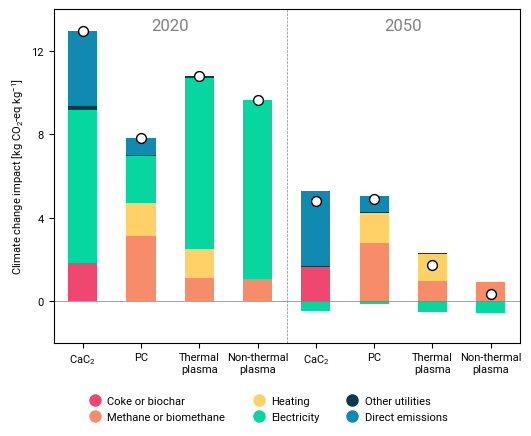

In [11]:
fig, ax1 = plt.subplots(1, 1, figsize = (fig_length[1.5], fig_height*0.4))

climate_change_df_2050_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)

ax1.legend([], frameon = False)

ax1.set_ylabel('Climate change impact [kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$]')

ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax1.scatter(x_pts, climate_change_df_2050['Total'], s = 50, facecolor = 'white', edgecolors = '#000000')
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)

ax1.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)

ax1.set_ylim([-2, 14])
ax1.text(1.5, 13.0, '2020', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax1.text(5.5, 13.0, '2050', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')

ax1.yaxis.set_major_locator(MaxNLocator(5))
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10) for color in colors]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.0), ncol = 3, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'plots', 'future_electricity_mix')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)

In [12]:
# climate_change_df_overall = pd.read_excel(os.path.join('..', 'results', climate_change_results_file), sheet_name = 'overall_combined', index_col = 0)
# climate_change_df_overall_final = climate_change_df_overall.drop(columns = 'Total')
# climate_change_df_overall_final

In [13]:
# x_pts = np.arange(0, len(climate_change_df_overall_final))
# x_labels = []
# for i in range(0, len(x_pts)):
#     string = climate_change_df_overall_final['Scenario'][i]
#     new = '\n'
#     string = new.join(string.rsplit(' ', 1))
#     x_labels.append(string)
# x_labels

In [14]:
# economics_df_overall = pd.read_excel(os.path.join('..', 'results', economics_results_file), sheet_name = 'overall_combined', index_col = 0)
# economics_df_overall_final = economics_df_overall.drop(columns = 'Total')
# economics_df_overall_final

In [15]:
# fig, [ax1, ax2] = plt.subplots(2, 1, figsize = (fig_length[2]*1.2, fig_height*0.8))

# climate_change_df_overall_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
# ax1.legend([], frameon = False)
# ax1.set_ylabel('Climate change impact [kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$]')
# ax1.set_xticks(x_pts)  
# ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
# ax1.scatter(x_pts, climate_change_df_overall['Total'], s = 50, facecolor = 'white', edgecolors = '#000000')
# ax1.set_title('a', fontsize = fontsize_title, fontweight = 'bold')
# ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
# ax1.axvline(x = 4.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax1.axvline(x = 9.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax1.set_ylim([-10, 15.2])
# ax1.text(2.0, 13.5, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax1.text(7.0, 13.5, 'Green (grid)', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax1.text(12.0, 13.5, 'Green (wind)', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax1.yaxis.set_major_locator(MaxNLocator(5))
# ax1.set_xticks([])

# economics_df_overall_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
# ax2.legend([], frameon = False)
# ax2.set_ylabel('Production costs [USD kg$^\mathdefault{-1}$]')
# ax2.set_xticks(x_pts)  
# ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
# ax2.scatter(x_pts, economics_df_overall['Total'], s = 50, facecolor = 'white', edgecolors = '#000000')
# ax2.set_title('b', fontsize = fontsize_title, fontweight = 'bold')
# ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
# ax2.axvline(x = 4.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax2.axvline(x = 9.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax2.set_ylim([0.1, 4.9])
# ax2.text(2.0, 4.6, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax2.text(7.0, 4.6, 'Green (grid)', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax2.text(12.0, 4.6, 'Green (wind)', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax2.yaxis.set_major_locator(MaxNLocator(5))

# handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10) for color in colors]
# legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.0), ncol = 6, frameon = False, handletextpad = 0.1)

# filepath = os.path.join('..', 'plots', 'main_figure_combined')
# plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
# plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)